# Lesson 26: multilayer perceptron activity

## Notebook set up
### Imports

In [1]:
# Third party imports
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, log_loss, ConfusionMatrixDisplay, accuracy_score 
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_sample_weight

## 1. Data preparation

### 1.1. Load diabetes dataset

#### EDA Utility Functions

In [2]:
data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print()
    print(df_info)
    print()

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{data_set_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{data_set_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
        
    print()

In [3]:
df_diabetes = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit3/diabetes_prediction_train.csv')
#df_diabetes.to_csv('DiabetesData.csv')

In [4]:
df_diabetes.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

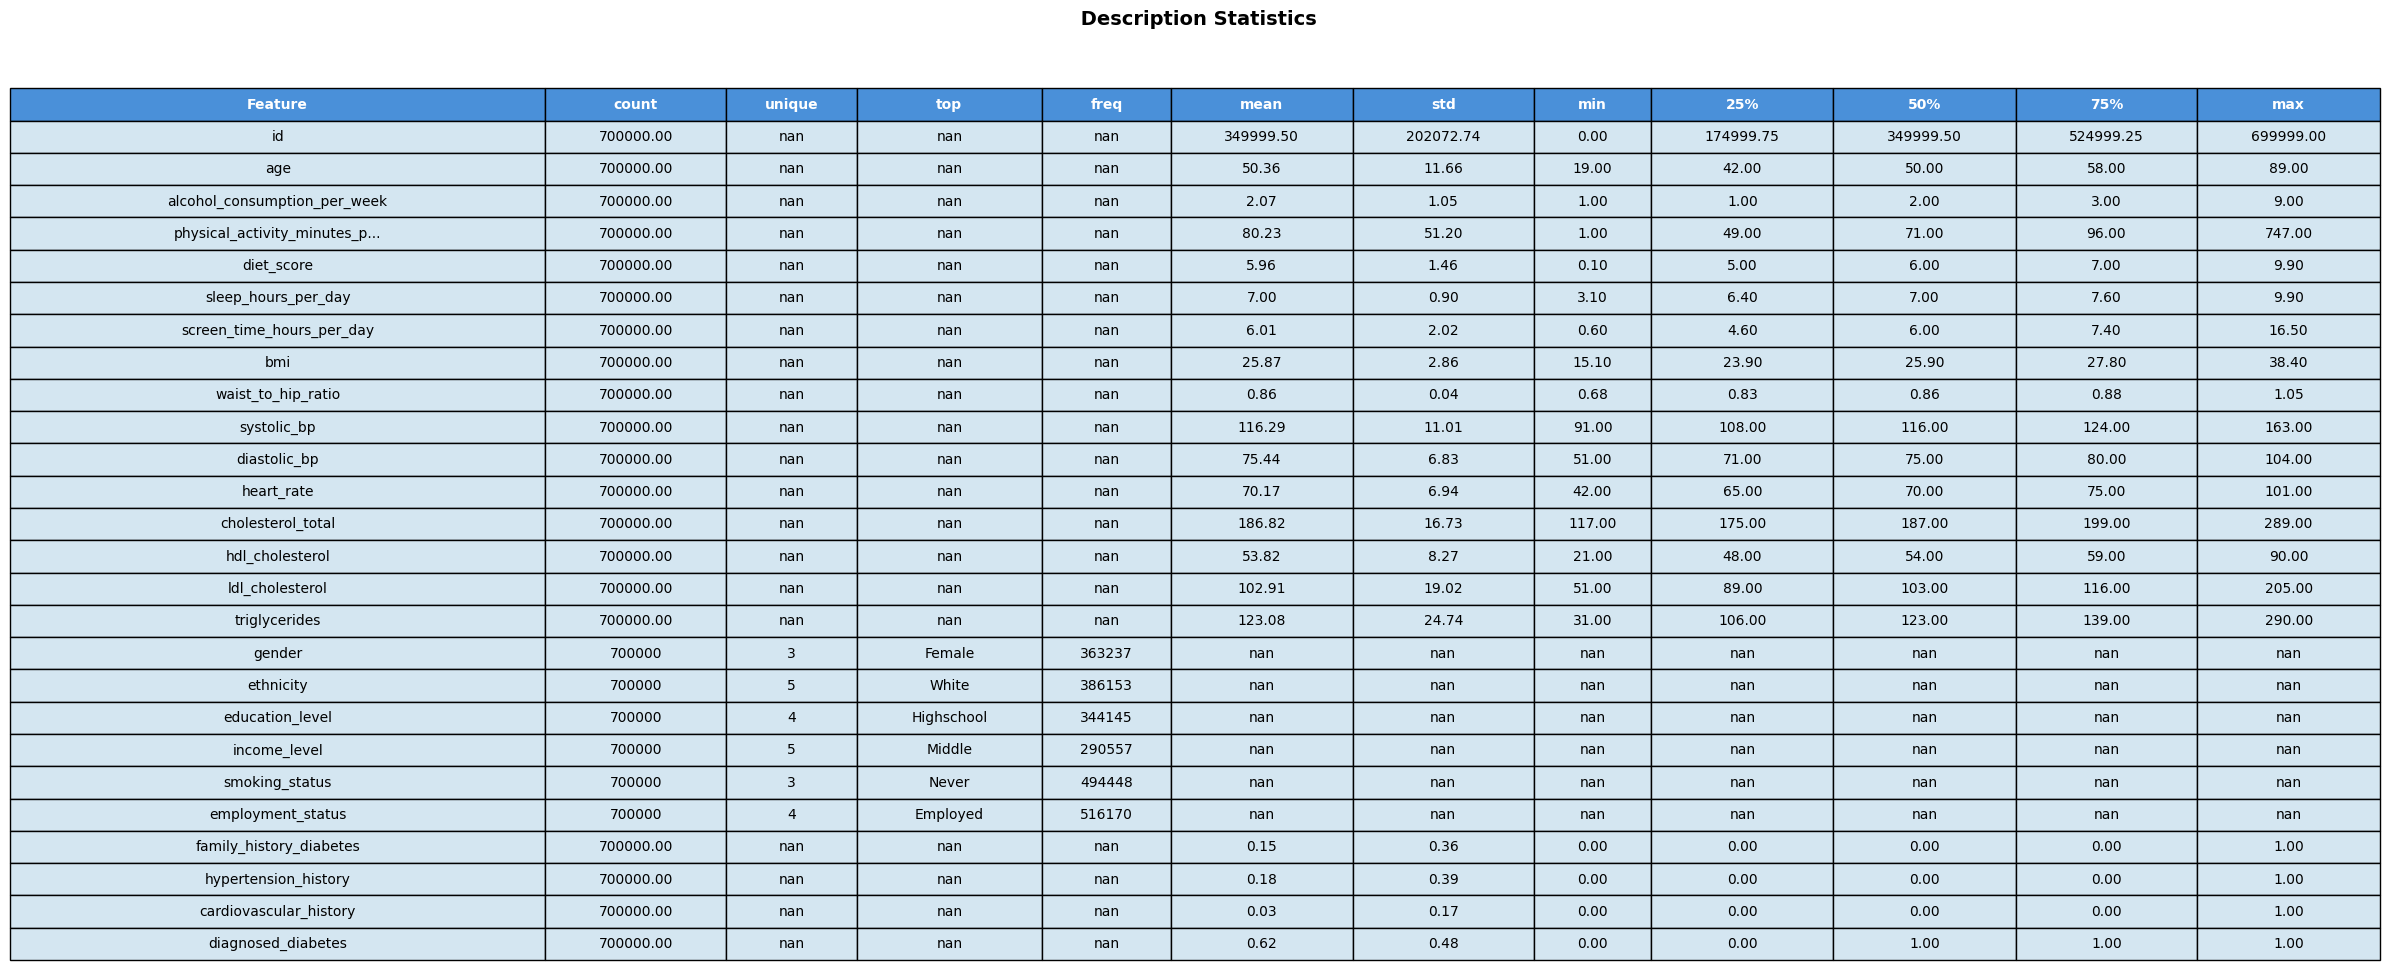

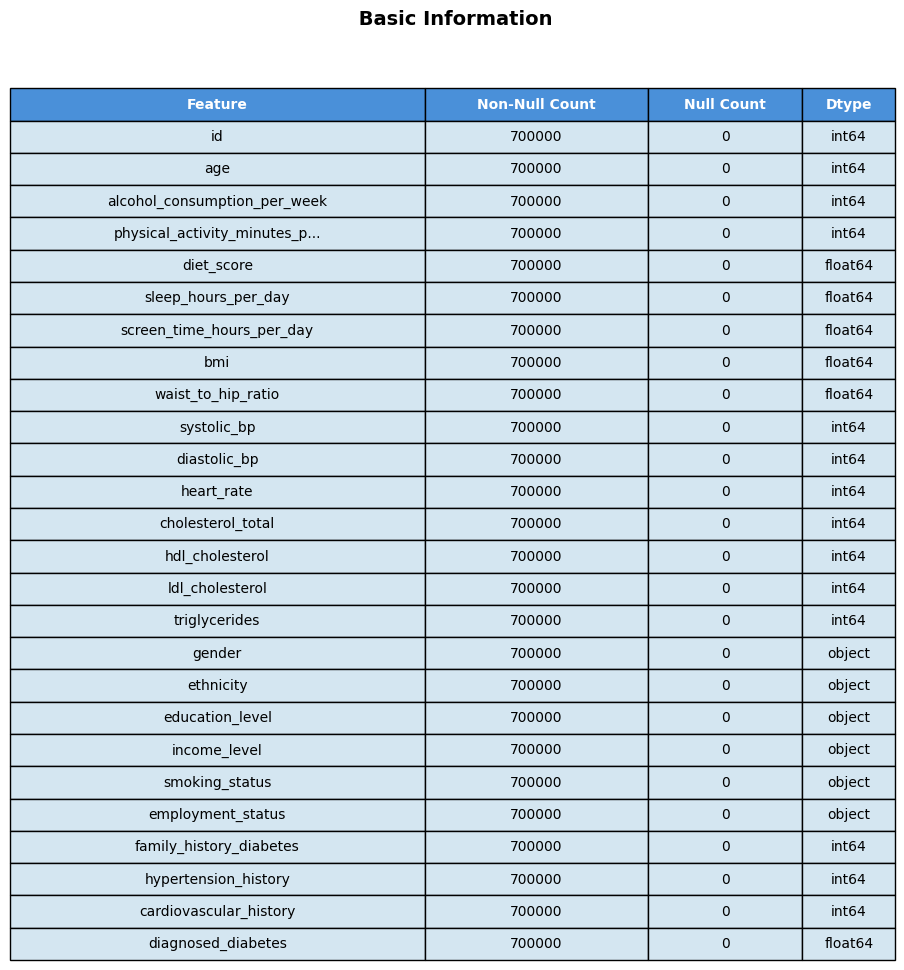

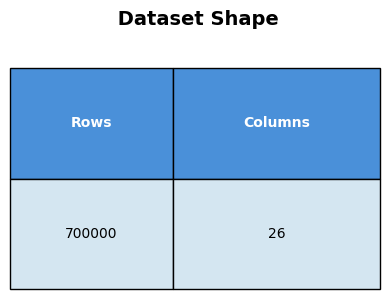




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



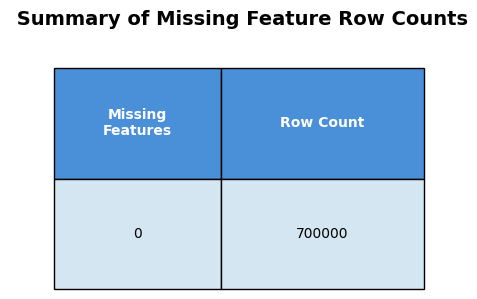

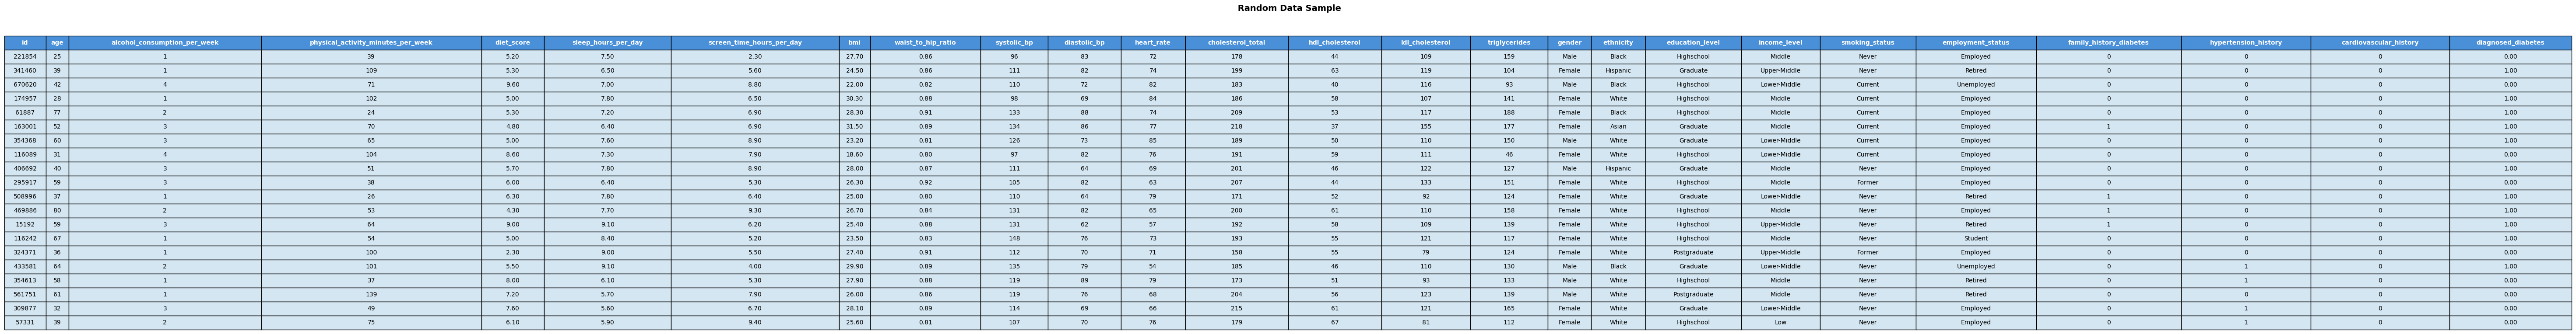

In [5]:
df_diabetes.info()

print()
PrintDataFrameStatistics(df_diabetes)

Define the label and feature columns below. The label is `diabetes` (binary: 0 or 1). Using separate lists for numerical, nominal and ordinal features makes preprocessing easier.

In [6]:
# Define the label
label = 'diagnosed_diabetes'

# Define numerical, ordinal and nominal features

numerical_features = df_diabetes.select_dtypes(include=['number']).columns.tolist()
print(numerical_features)

ordinal_features=['education_level', 'income_level']
nominal_features=['gender', 'ethnicity', 'smoking_status', 'employment_status']

# Complete feature list
features = numerical_features + ordinal_features + nominal_features

['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes']


In [7]:
# Select the features of interest and the label
features.remove(label)
numerical_features.remove(label)
print(label)
print(features)

diagnosed_diabetes
['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level', 'income_level', 'gender', 'ethnicity', 'smoking_status', 'employment_status']


### 1.2. Train test split

Use `train_test_split` to split the data into training and testing sets. Use `random_state=315` for reproducibility.

In [8]:
# df_training, df_testing = train_test_split(df_diabetes, random_state=315)

X = df_diabetes[features]
y = df_diabetes[label]

df_training, df_testing = train_test_split(df_diabetes, random_state=315)


### 1.3. Preprocess numerical features

#### 1.3.1. Standard scale

Neural networks perform better when features are scaled. Use `StandardScaler` to fit on the training features and transform both training and testing features.

**Hint:** Fit the scaler on `training_df[numerical_features]`, then transform both `training_df[numerical_features]` and `testing_df[numerical_features]`.

In [9]:
# YOUR CODE HERE: fit and transform the numerical features
feature_scaler = StandardScaler()
feature_scaler.fit(df_training[numerical_features])

df_training[numerical_features] = feature_scaler.transform(df_training[numerical_features])
df_testing[numerical_features] = feature_scaler.transform(df_testing[numerical_features])

#### 1.3.2. Clip outliers with IQR method

In [10]:
# YOUR CODE HERE: implement IQR clipping for numerical features
for feature in numerical_features:

    q1 = df_training[feature].quantile(0.25)
    q3 = df_training[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_training[feature] = df_training[feature].clip(lower=lower_bound, upper=upper_bound)
    df_testing[feature] = df_testing[feature].clip(lower=lower_bound, upper=upper_bound)

### 1.4. Preprocess categorical features

#### 1.4.1. Ordinal feature encoding

Unique education_level Values


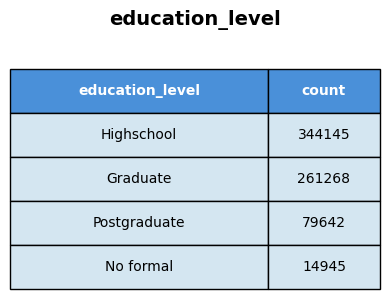



Unique income_level Values


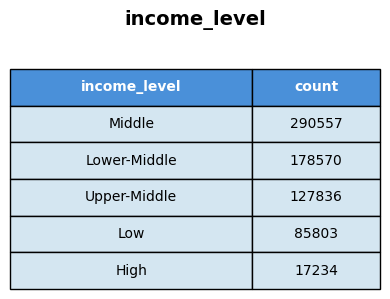




        education_level  income_level
160297              2.0           2.0
552737              2.0           3.0
157506              2.0           3.0
342933              1.0           2.0
193272              2.0           1.0
628171              2.0           2.0
639859              1.0           2.0
181272              2.0           2.0
1232                1.0           1.0
532475              2.0           0.0
133738              2.0           2.0
198801              2.0           2.0
66363               2.0           1.0
299890              2.0           3.0
109166              1.0           1.0
644024              2.0           2.0
523932              1.0           3.0
49551               1.0           2.0
119126              3.0           0.0
430929              1.0           2.0
289964              1.0           1.0
361473              1.0           0.0
393110              1.0           2.0
203971              1.0           2.0
17827               2.0           2.0
690610   

In [11]:
# YOUR CODE HERE: create and fit OrdinalEncoder, then transform both training and testing data

def DisplayUniqueValues(feature_name):
    print(f'Unique {feature_name} Values')
    df_target = df_diabetes[feature_name].value_counts().reset_index()
    DisplayTable(df_target, table_title=feature_name)    

list(map(DisplayUniqueValues, ordinal_features))
print()

educational_order = ['No formal', 'Highschool', 'Graduate', 'Postgraduate']
income_order = ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']

ordinal_encoder = OrdinalEncoder(categories=[educational_order, income_order])
df_training[ordinal_features] = ordinal_encoder.fit_transform(df_training[ordinal_features])
df_testing[ordinal_features] = ordinal_encoder.transform(df_testing[ordinal_features])

print(df_training[ordinal_features].sample(40))
#list(map(DisplayUniqueValues, ordinal_features))
#PrintDataFrameStatistics(df_diabetes)


#### 1.4.2. Nominal feature encoding

In [12]:
# YOUR CODE HERE: create and fit OneHotEncoder, transform features, and concatenate back to dataframes
onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit on training data, transform both
encoded_training = onehot_encoder.fit_transform(df_training[nominal_features])
encoded_testing = onehot_encoder.transform(df_testing[nominal_features])

# Get new column names
encoded_columns = onehot_encoder.get_feature_names_out(nominal_features)
print(encoded_columns)

# Create DataFrames with encoded columns
df_encoded_training = pd.DataFrame(encoded_training, columns=encoded_columns, index=df_training.index)
df_encoded_testing = pd.DataFrame(encoded_testing, columns=encoded_columns, index=df_testing.index)

# Drop original nominal columns and add encoded columns
df_training = df_training.drop(columns=nominal_features)
df_training = pd.concat([df_training, df_encoded_training], axis=1)

df_testing = df_testing.drop(columns=nominal_features)
df_testing = pd.concat([df_testing, df_encoded_testing], axis=1)
print()

['gender_Male' 'gender_Other' 'ethnicity_Black' 'ethnicity_Hispanic'
 'ethnicity_Other' 'ethnicity_White' 'smoking_status_Former'
 'smoking_status_Never' 'employment_status_Retired'
 'employment_status_Student' 'employment_status_Unemployed']



#### 1.4.3. Update the feature list

['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'education_level', 'income_level', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'gender_Male', 'gender_Other', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White', 'smoking_status_Former', 'smoking_status_Never', 'employment_status_Retired', 'employment_status_Student', 'employment_status_Unemployed']
***********************************
Description Stats
***********************************

                               Feature     count          mean           std  \
0                                   id  525000.0  1.049708e-16  1.000001e+00   
1                                  age  525000.0 -1.330979e-04  9.995947e-01   
2         alco

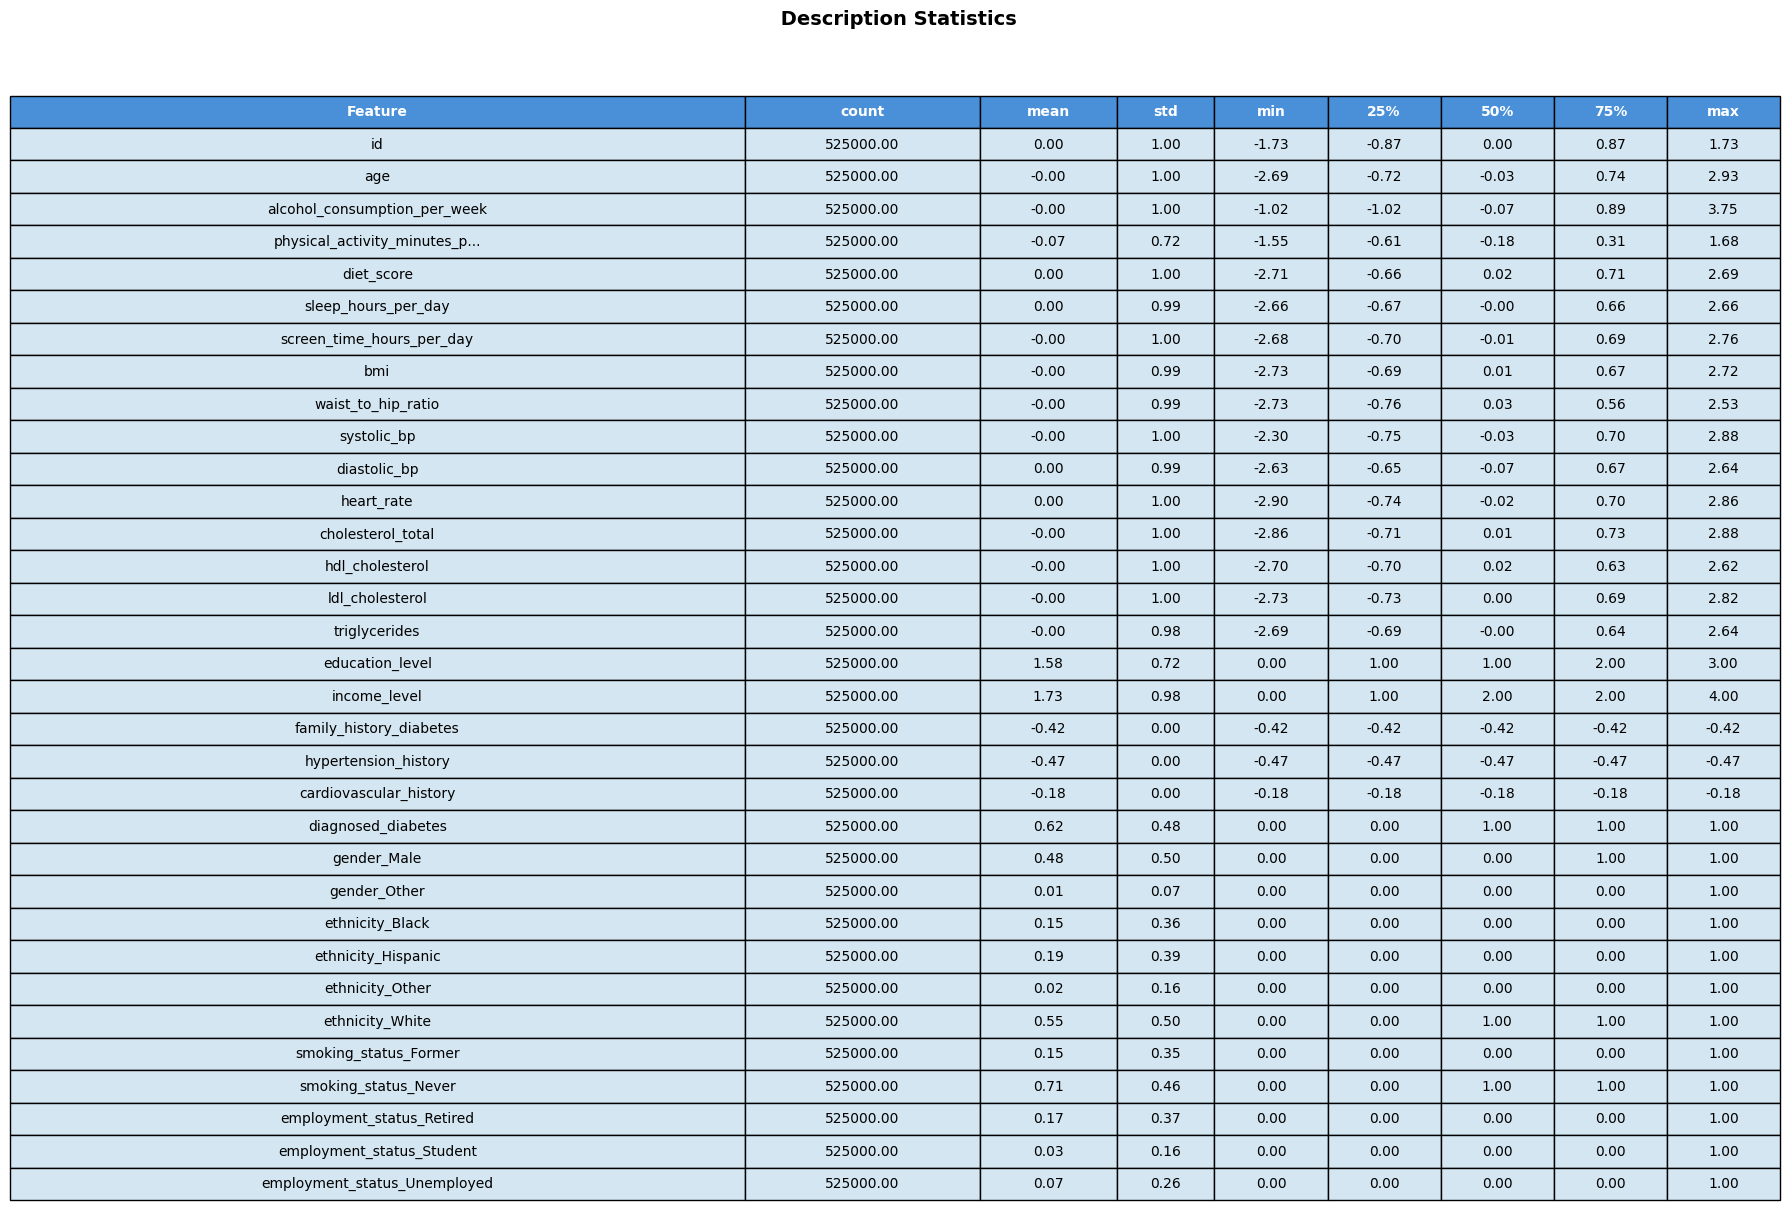

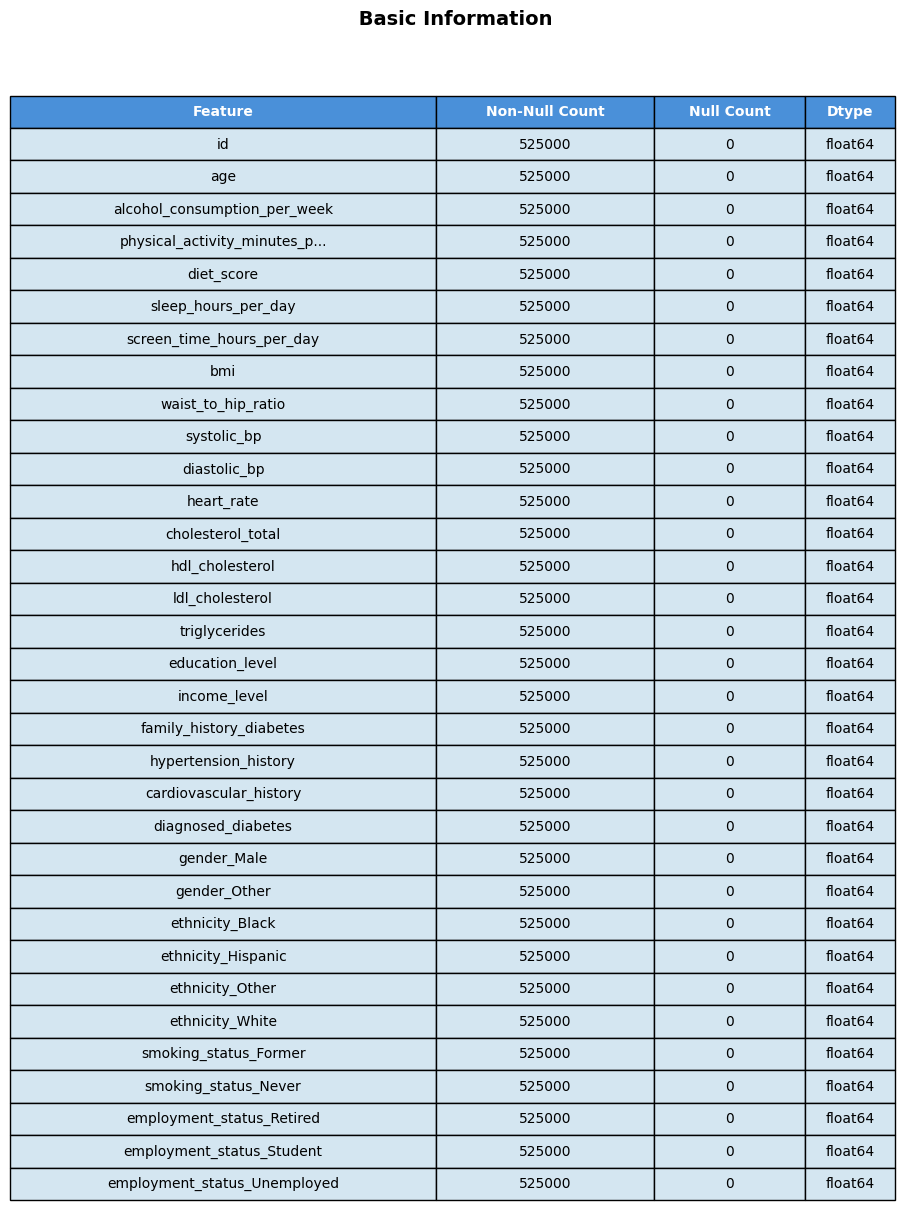

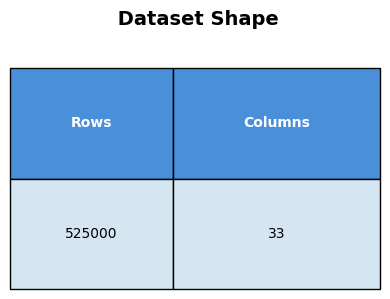




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



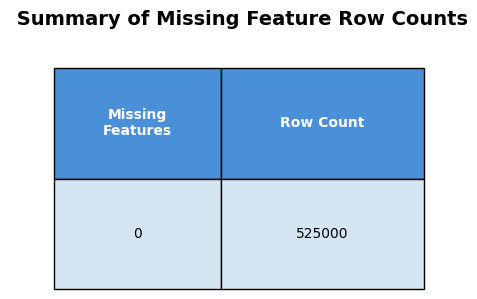

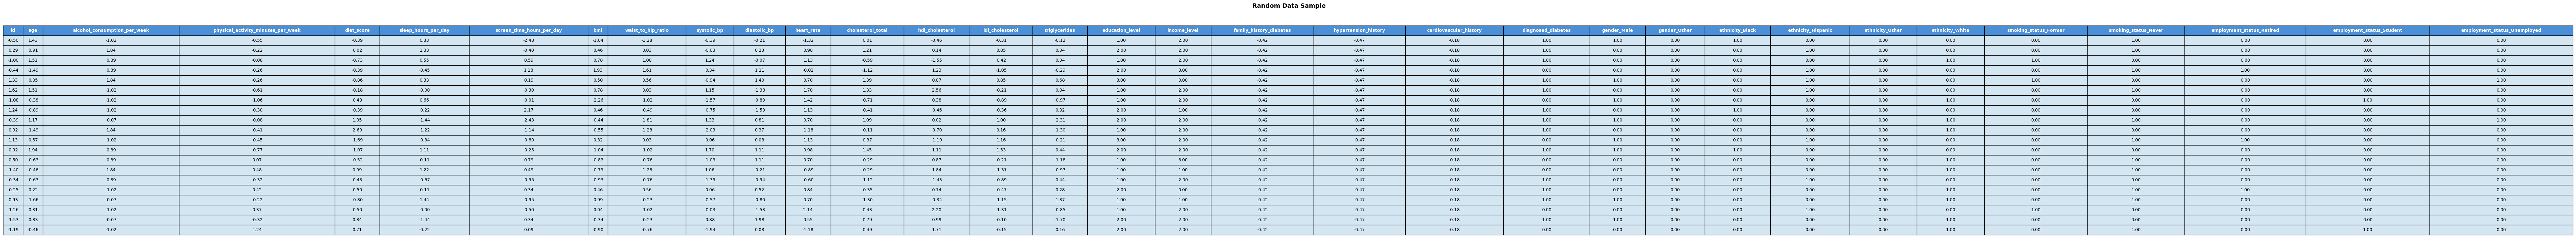

In [13]:
# YOUR CODE HERE: update the features list to include encoded features and remove the label
features = [col for col in df_training.columns if col not in [label, 'id']]
print(features)
PrintDataFrameStatistics(df_training)

#### 1.4.4. Min/max scale categorical features

In [14]:
# YOUR CODE HERE: create MinMaxScaler with feature_range=(-1, 1), fit on categorical features, and transform
scaler = MinMaxScaler(feature_range=(-1,1))

# Fit on training, transform both
# Not sure if this the best approach for minmax scaling - all numerical columns
# Binary Values 0/1 will become -1/1 - but shouldn't affect model performance
df_training[numerical_features] = scaler.fit_transform(df_training[numerical_features])
df_testing[numerical_features] = scaler.transform(df_testing[numerical_features])

In [15]:
df_training.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525000 entries, 261849 to 422499
Data columns (total 33 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  525000 non-null  float64
 1   age                                 525000 non-null  float64
 2   alcohol_consumption_per_week        525000 non-null  float64
 3   physical_activity_minutes_per_week  525000 non-null  float64
 4   diet_score                          525000 non-null  float64
 5   sleep_hours_per_day                 525000 non-null  float64
 6   screen_time_hours_per_day           525000 non-null  float64
 7   bmi                                 525000 non-null  float64
 8   waist_to_hip_ratio                  525000 non-null  float64
 9   systolic_bp                         525000 non-null  float64
 10  diastolic_bp                        525000 non-null  float64
 11  heart_rate                

## 2. Logistic regression model

Logistic regression is a linear model for classification. It serves as a good baseline before trying more complex models like neural networks.

### 2.1. Fit

Create a `LogisticRegression` model and fit it on the training data. Use `max_iter=1000` to ensure convergence.

In [16]:

# Separate after all preprocessing completed
#
X_train = df_training[features]
y_train = df_training[label]
X_test = df_testing[features]
y_test = df_testing[label]


model = LogisticRegression(random_state=315, max_iter=1000, class_weight='balanced')
fit_result = model.fit(X_train, y_train)


### 2.2. Test set evaluation

For classification, we can use accuracy, F1 score and/or AUC-ROC (and others) instead of R². Use sklearn's [`metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) module .

In [17]:
logistic_predictions = fit_result.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)

logistic_f1 = f1_score(y_test, logistic_predictions)

logistic_auc = roc_auc_score(y_test, fit_result.predict_proba(X_test)[:, 1])

print(f'Logistic regression accuracy on test set: {logistic_accuracy:.4f}')
print(f'Logistic regression F1 score on test set: {logistic_f1:.4f}')
print(f'Logistic regression AUC-ROC score on test set: {logistic_auc:.4f}')

Logistic regression accuracy on test set: 0.6109
Logistic regression F1 score on test set: 0.6658
Logistic regression AUC-ROC score on test set: 0.6509


### 2.3. Performance analysis

For classification, visualize performance using a confusion matrix.

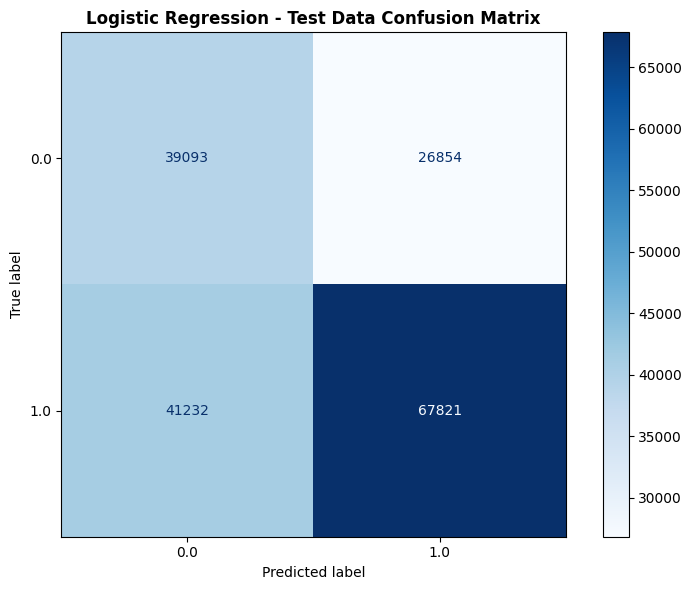

In [18]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, logistic_predictions, ax=ax, cmap='Blues')
plt.title('Logistic Regression - Test Data Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print()


## 3. Multilayer perceptron (MLP) classifier

Now let's build a neural network classifier using sklearn's [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

### 3.1. Single epoch training function

Complete the training function below. It should:
1. Split the data into training and validation sets
2. Call `partial_fit` on the model (remember to pass `classes=[0, 1]` on the first call)
3. Record training and validation [`log_loss`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html) (aka binary cross-entropy) in the history dictionary

**Hint:** Use `model.partial_fit(X, y, classes=[0, 1])` for the first epoch. For subsequent epochs, `partial_fit` remembers the classes.

In [19]:
def train(model: MLPClassifier, df: pd.DataFrame, training_history: dict, classes: list = None) -> tuple[MLPClassifier, dict]:
    '''Trains sklearn MLP classifier model on given dataframe using validation split.
    Returns the updated model and training history dictionary containing training and
    validation log loss. If classes are not provided, assumes 0 and 1.'''

    global features, label

    df, val_df = train_test_split(df, random_state=315)

    # Compute balanced sample weights
    sample_weights = compute_sample_weight('balanced', df[label])

    # model.partial_fit(X, y, classes=[0, 1])
    #model.partial_fit(df[features], df[label], classes=[0,1], sample_weight=sample_weights)
    model.partial_fit(df[features], df[label], classes=[0,1])

    # Calculate log_loss using predict_proba
    train_prob = model.predict_proba(df[features])
    val_prob = model.predict_proba(val_df[features])

    training_history['training_loss'].append(log_loss(df[label], train_prob))
    training_history['validation_loss'].append(log_loss(val_df[label], val_prob))

    return model, training_history

### 3.2. Model training

Create an `MLPClassifier` with:
- `hidden_layer_sizes=(64, 32)` - two hidden layers
- `activation='relu'` - ReLU activation function
- `learning_rate_init=0.001` - initial learning rate
- `warm_start=True` - keep weights between calls to fit
- `random_state=315` - for reproducibility

Train for 10 epochs using the training function above.

In [20]:
epochs = 1000

training_history = {
    'training_loss': [],
    'validation_loss': []
}

mlp_model = MLPClassifier(
                            hidden_layer_sizes=(64, 32, 64), #hidden_layer_sizes=(64, 32, 64, 32, 16, 8),
                            activation='relu',
                            learning_rate_init=0.0001,
                            warm_start=True,
                            random_state=315
                        )

for epoch in range(epochs):

    mlp_model, training_history = train(mlp_model, df_training, training_history)
  
    print(
        f'Epoch {epoch+1}/{epochs} - ' +
        f'training log_loss: {training_history["training_loss"][-1]:.4f} - ' +
        f'validation log_loss: {training_history["validation_loss"][-1]:.4f}'
    )

Epoch 1/1000 - training log_loss: 0.6281 - validation log_loss: 0.6287
Epoch 2/1000 - training log_loss: 0.6274 - validation log_loss: 0.6283
Epoch 3/1000 - training log_loss: 0.6271 - validation log_loss: 0.6281
Epoch 4/1000 - training log_loss: 0.6269 - validation log_loss: 0.6279
Epoch 5/1000 - training log_loss: 0.6268 - validation log_loss: 0.6278
Epoch 6/1000 - training log_loss: 0.6266 - validation log_loss: 0.6278
Epoch 7/1000 - training log_loss: 0.6265 - validation log_loss: 0.6277
Epoch 8/1000 - training log_loss: 0.6264 - validation log_loss: 0.6277
Epoch 9/1000 - training log_loss: 0.6263 - validation log_loss: 0.6276
Epoch 10/1000 - training log_loss: 0.6262 - validation log_loss: 0.6276
Epoch 11/1000 - training log_loss: 0.6261 - validation log_loss: 0.6276
Epoch 12/1000 - training log_loss: 0.6261 - validation log_loss: 0.6276
Epoch 13/1000 - training log_loss: 0.6260 - validation log_loss: 0.6275
Epoch 14/1000 - training log_loss: 0.6259 - validation log_loss: 0.6275
E

### 3.3. Learning curves

Plot the training and validation loss over epochs to visualize the learning process.

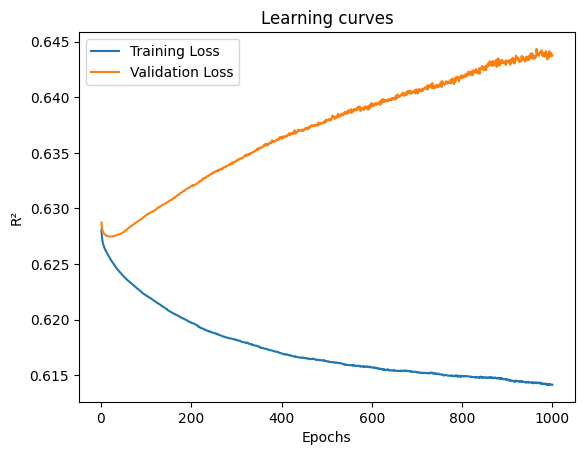

In [21]:
# YOUR CODE HERE: plot training and validation loss
plt.plot(
    range(1, epochs + 1), training_history['training_loss'],
    label='Training Loss'
)
plt.plot(
    range(1, epochs + 1), training_history['validation_loss'],
    label='Validation Loss'
)
plt.title('Learning curves')
plt.xlabel('Epochs')
plt.ylabel('R²')
plt.legend()
plt.show()

### 3.4. Test set evaluation

Evaluate the MLP model on the test set, similar to how you evaluated the logistic regression model.

In [22]:
mlp_predictions = mlp_model.predict(df_testing[features])

mlp_accuracy = accuracy_score(y_test, mlp_predictions)

mlp_f1 = f1_score(y_test, mlp_predictions)

mlp_auc = roc_auc_score(y_test, mlp_model.predict_proba(X_test)[:, 1])

print(f'MLP accuracy on test set: {mlp_accuracy:.4f}')
print(f'MLP F1 score on test set: {mlp_f1:.4f}')
print(f'MLP AUC-ROC score on test set: {mlp_auc:.4f}')

MLP accuracy on test set: 0.6414
MLP F1 score on test set: 0.7495
MLP AUC-ROC score on test set: 0.6343


### 3.5. Performance analysis

Create a confusion matrix for the MLP model predictions.

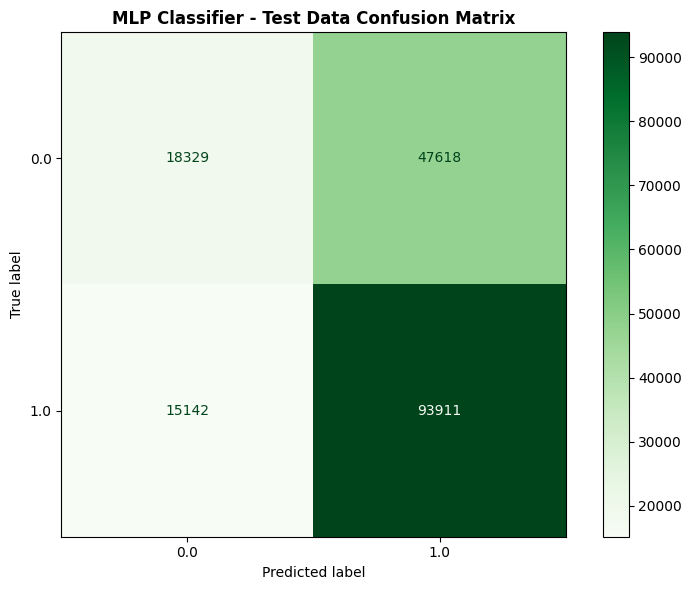

In [23]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, mlp_predictions, ax=ax, cmap='Greens')
plt.title('MLP Classifier - Test Data Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print()

## 4. Model comparison

Compare the performance of both models side by side.

In [24]:
print(f'Logistic Regression accuracy on test set: {logistic_accuracy:.4f}')
print(f'MLP accuracy on test set: {mlp_accuracy:.4f}')

Logistic Regression accuracy on test set: 0.6109
MLP accuracy on test set: 0.6414


Create a side-by-side comparison of the confusion matrices for both models.

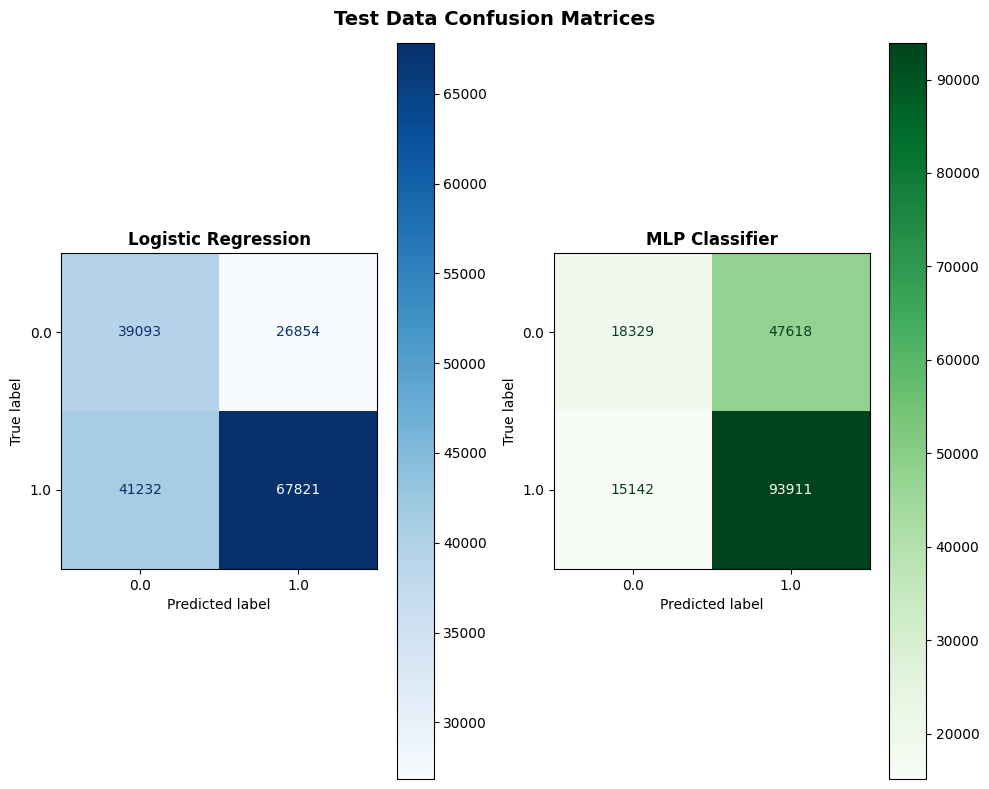


diagnosed_diabetes
1.0    327254
0.0    197746
Name: count, dtype: int64
diagnosed_diabetes
1.0    0.623341
0.0    0.376659
Name: proportion, dtype: float64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes = axes.flatten()

ConfusionMatrixDisplay.from_predictions(y_test, logistic_predictions, ax=axes[0], cmap='Blues', values_format='d')
ConfusionMatrixDisplay.from_predictions(y_test, mlp_predictions, ax=axes[1], cmap='Greens', values_format='d')

axes[0].set_title('Logistic Regression', fontweight='bold')
axes[1].set_title('MLP Classifier', fontweight='bold')

fig.suptitle('Test Data Confusion Matrices', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()
print()

print(y_train.value_counts())
print(y_train.value_counts(normalize=True))